<div align="center">

#### Lab 3

# National Tsing Hua University

#### Spring 2025

#### 11320IEEM 513600

#### Deep Learning and Industrial Applications
    
## Lab 3: Anomaly Detection in Industrial Applications

</div>

### Introduction

In today's industrial landscape, the ability to detect anomalies in manufacturing processes and products is critical for maintaining quality, efficiency, and safety. This lab focuses on leveraging deep learning techniques for anomaly detection in various industrial applications, using the MVTEC Anomaly Detection Dataset. By employing ImageNet-pretrained models available in torchvision, students will gain hands-on experience in classfying defects and irregularities across different types of industrial products.

Throughout this lab, you'll be involved in the following key activities:
- Explore and process the MVTec Anomaly Detection Dataset.
- Apply ImageNet-pretrained models from [Torchvision](https://pytorch.org/vision/stable/models.html) to detect anomalies in industrial products.
- Evaluate the performance of the models to understand their effectiveness in real-world industrial applications.

### Objectives

- Understand the principles of anomaly detection in the context of industrial applications.
- Learn how to implement and utilize ImageNet-pretrained models for detecting anomalies.
- Analyze and interpret the results of the anomaly detection models to assess their practicality in industrial settings.

### Dataset

The MVTec AD Dataset is a comprehensive collection of high-resolution images across different categories of industrial products, such as bottles, cables, and metal nuts, each with various types of defects. This dataset is pivotal for developing and benchmarking anomaly detection algorithms. You can download our lab's dataset [here](https://drive.google.com/file/d/19600hUOpx0hl78TdpdH0oyy-gGTk_F_o/view?usp=share_link). You can drop downloaded data and drop to colab, or you can put into yor google drive.

### References
- [MVTec AD Dataset](https://www.kaggle.com/datasets/ipythonx/mvtec-ad/data) for the dataset used in this lab.
- [Torchvision Models](https://pytorch.org/vision/stable/models.html) for accessing ImageNet-pretrained models to be used in anomaly detection tasks.
- [State-of-the-Art Anomaly Detection on MVTec AD](https://paperswithcode.com/sota/anomaly-detection-on-mvtec-ad) for insights into the latest benchmarks and methodologies in anomaly detection applied to the MVTec AD dataset.
- [CVPR 2019: MVTec AD — A Comprehensive Real-World Dataset for Unsupervised Anomaly Detection] for the original paper of MVTec AD dataset.

In [1]:
import glob
import matplotlib.pyplot as plt
import random
from tqdm.auto import tqdm
import cv2
import numpy as np

In [2]:
from google.colab import drive

drive.mount('/content/drive')
!tar -xvf /content/drive/MyDrive/Colab_Notebooks/深度學習HW3/cable.tar.gz cable

Mounted at /content/drive
cable/
cable/cable_swap/
cable/cable_swap/004.png
cable/cable_swap/009.png
cable/cable_swap/005.png
cable/cable_swap/002.png
cable/cable_swap/001.png
cable/cable_swap/000.png
cable/cable_swap/008.png
cable/cable_swap/010.png
cable/cable_swap/011.png
cable/cable_swap/006.png
cable/cable_swap/003.png
cable/cable_swap/007.png
cable/.DS_Store
cable/cut_inner_insulation/
cable/cut_inner_insulation/004.png
cable/cut_inner_insulation/009.png
cable/cut_inner_insulation/005.png
cable/cut_inner_insulation/002.png
cable/cut_inner_insulation/001.png
cable/cut_inner_insulation/012.png
cable/cut_inner_insulation/000.png
cable/cut_inner_insulation/008.png
cable/cut_inner_insulation/010.png
cable/cut_inner_insulation/013.png
cable/cut_inner_insulation/011.png
cable/cut_inner_insulation/006.png
cable/cut_inner_insulation/003.png
cable/cut_inner_insulation/007.png
cable/cut_outer_insulation/
cable/cut_outer_insulation/004.png
cable/cut_outer_insulation/009.png
cable/cut_outer_i

In [3]:
file_paths = glob.glob('cable/*/*.png')
#file_paths = sorted([path for path in file_paths if path.split('/')[-1] in [f'{i:03}.png' for i in range(10)]])
file_paths = sorted([path for path in file_paths])
print(f'number of pictures:{len(file_paths)}')

number of pictures:139


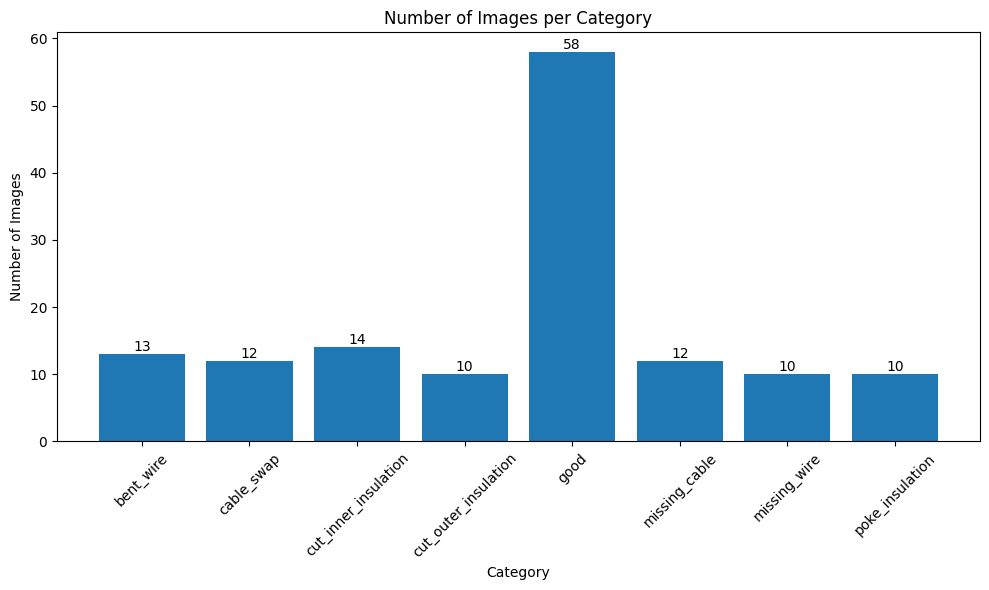

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

# 計算每個種類的照片有幾張
categories = [path.split('/')[-2] for path in file_paths]
category_counts = Counter(categories)

# Plotting the category counts
categories = sorted(list(category_counts.keys()))
counts = list(category_counts.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             str(count), ha='center', va='bottom', fontsize=10)

plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Number of Images per Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
all_data = []

for img in tqdm(file_paths):
    img = cv2.imread(img)
    img = img[..., ::-1]
    all_data.append(img)

all_data = np.stack(all_data)
print(all_data.shape)

  0%|          | 0/139 [00:00<?, ?it/s]

(139, 1024, 1024, 3)


Classes: ['bent_wire', 'cable_swap', 'cut_inner_insulation', 'cut_outer_insulation', 'good', 'missing_cable', 'missing_wire', 'poke_insulation']


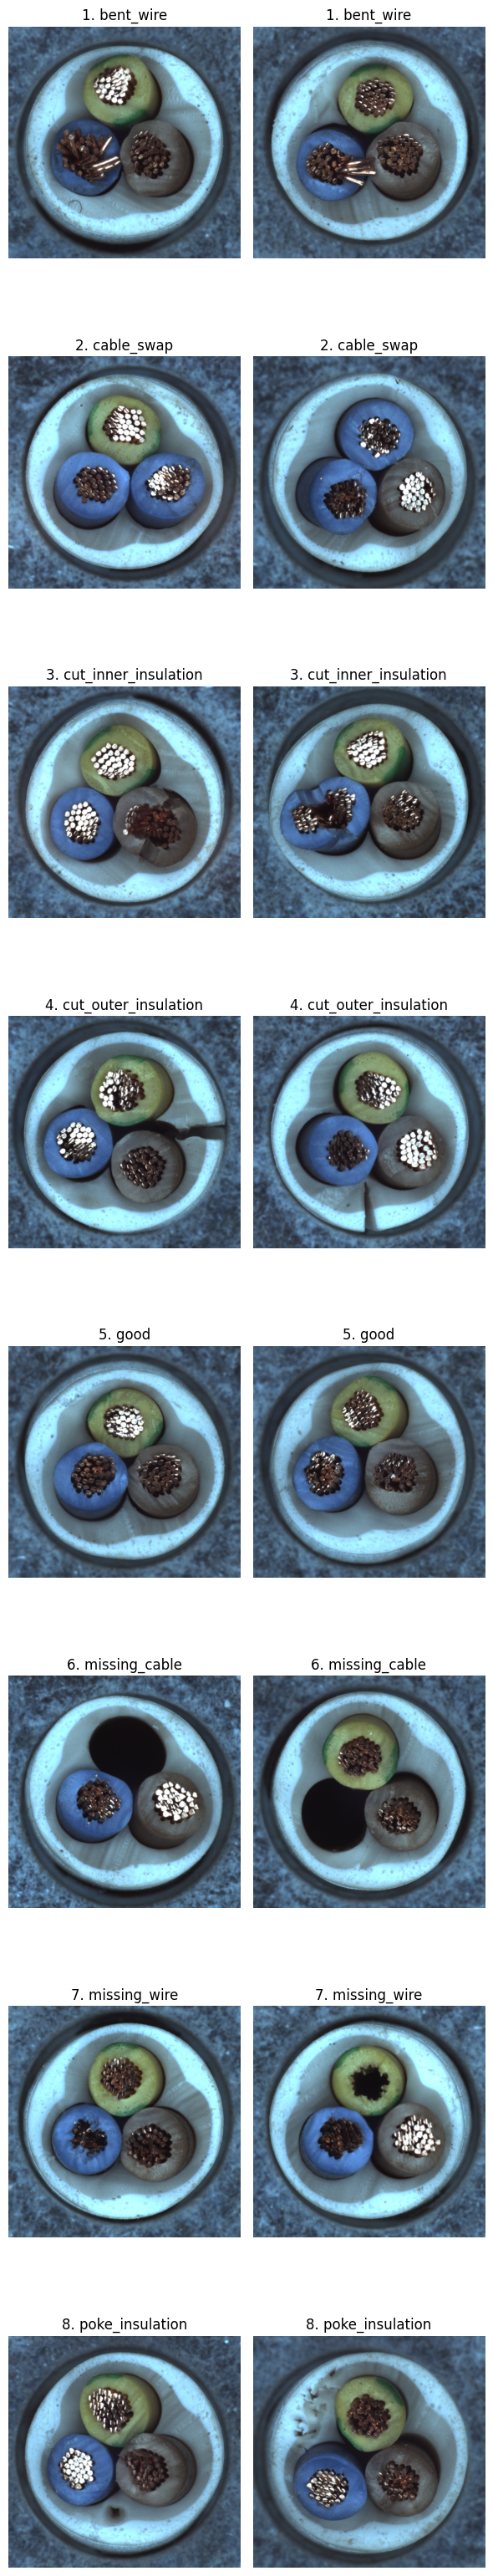

In [6]:
print(f'Classes: {categories}')

# 找到每個 Class 最開始的 index [0, 13, 25, 39....]
cumulative_counts = [0] + list(np.cumsum(list(category_counts.values())))

fig, axs = plt.subplots(len(categories), 2, figsize=(6, 4 * len(categories)))

for i, class_name in enumerate(categories):

    start_index = cumulative_counts[i]

    for j in range(2):
        axs[i, j].imshow(all_data[start_index + j])
        axs[i, j].axis('off')
        axs[i, j].set_title(f'{i+1}. {class_name}')

plt.tight_layout()
plt.show()

## A. Data Loading and Preprocessing

In [7]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np

# Assuming category_counts is a Counter object containing image counts per category
# Example: category_counts = Counter({'category1': 15, 'category2': 12, 'category3': 18, ...})

x_train = []
x_val = []
y_train = []
y_val = []

# Cumulative count to track image indices across categories
cumulative_count = 0

for category_index, (category_name, image_count) in enumerate(category_counts.items()):
    # Calculate split indices for this category
    train_images_per_class = int(image_count * 0.8)
    val_images_per_class = image_count - train_images_per_class

    # Extract images for this category
    category_images = all_data[cumulative_count : cumulative_count + image_count]

    # Split into train and validation
    x_train.extend(category_images[:train_images_per_class])
    x_val.extend(category_images[train_images_per_class:])

    # Create labels for this category
    y_train.extend([category_index] * train_images_per_class)
    y_val.extend([category_index] * val_images_per_class)

    # Update cumulative count for the next category
    cumulative_count += image_count

# Convert to NumPy arrays and transpose
x_train = np.transpose(np.array(x_train), (0, 3, 1, 2))
x_val = np.transpose(np.array(x_val), (0, 3, 1, 2))
y_train = np.array(y_train)
y_val = np.array(y_val)

print(f'Shape of x_train: {x_train.shape}')
print(f'Shape of x_val: {x_val.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_val: {y_val.shape}')

Shape of x_train: (109, 3, 1024, 1024)
Shape of x_val: (30, 3, 1024, 1024)
Shape of y_train: (109,)
Shape of y_val: (30,)


In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image

train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.AutoAugment(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

class MyDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = torch.from_numpy(y).long()
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        new_x = np.transpose(self.x[idx], (1, 2, 0))
        return self.transform(Image.fromarray(new_x)), self.y[idx]

In [13]:
batch_size = 8

train_dataset = MyDataset(x_train, y_train, train_transforms)
val_dataset = MyDataset(x_val, y_val, val_transforms)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=True, persistent_workers=True)

## B. Defining Neural Networks

In [134]:
# import torch.nn as nn
# import torch.nn.functional as F
# from torchvision import models

# model = models.resnet18(weights='IMAGENET1K_V1')

# # ConvNet as fixed feature extractor (freeze parameters)
# for param in model.parameters():
#     param.requires_grad = False

# num_ftrs = model.fc.in_features
# num_class = 8

# # change # of class from 1000 into 8 in the last layer
# model.fc = nn.Linear(num_ftrs, num_class)
# print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
import torch.nn as nn
from torchvision import models

# 載入 MobileNetV2 預訓練模型
model = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Freeze 所有參數（不進行訓練）
for param in model.parameters():
    param.requires_grad = False

# 修改最後分類層：將原本 1000 類改為 8 類
num_ftrs = model.classifier[1].in_features
num_class = 8
model.classifier[1] = nn.Linear(num_ftrs, num_class)

print(model)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

## C. Training the Neural Network

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm

# 記錄用
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# 訓練設定
epochs = 75
model = model.cuda()
best_val_loss = float('inf')
best_val_acc = -1

# 損失函數 & optimizer & scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

# 使用 ReduceLROnPlateau：根據 val loss 沒進步自動降低 LR
lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

for epoch in tqdm(range(epochs)):
    # === Training ===
    model.train()
    total_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for images, labels in train_loader:
        images = images.cuda()
        images = images / 255.  # normalize to [0, 1]
        labels = labels.cuda().long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        train_predicted = outputs.argmax(-1)
        train_correct += (train_predicted == labels).sum().item()
        total_train_samples += labels.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = 100. * train_correct / total_train_samples

    # === Validation ===
    model.eval()
    total_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            images = images / 255.
            labels = labels.cuda().long()
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            predicted = outputs.argmax(-1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100. * correct / total

    # 更新 learning rate（根據 val loss）
    lr_scheduler.step(avg_val_loss)

    # 儲存最佳模型
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'model_classification.pth')

    # 印出結果
    print(f'Epoch {epoch+1}/{epochs}, '
          f'Train loss: {avg_train_loss:.4f}, Train acc: {train_accuracy:.2f}%, '
          f'Val loss: {avg_val_loss:.4f}, Val acc: {val_accuracy:.2f}%, '
          f'Best Val loss: {best_val_loss:.4f}, Best Val acc: {best_val_acc:.2f}%')

    # 紀錄數據
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)


  0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/75, Train loss: 7.0104, Train acc: 19.27%, Val loss: 3.9254, Val acc: 40.00%, Best Val loss: 3.9254, Best Val acc: 40.00%
Epoch 2/75, Train loss: 4.0337, Train acc: 34.86%, Val loss: 3.4127, Val acc: 40.00%, Best Val loss: 3.4127, Best Val acc: 40.00%
Epoch 3/75, Train loss: 2.3695, Train acc: 41.28%, Val loss: 3.9957, Val acc: 10.00%, Best Val loss: 3.4127, Best Val acc: 40.00%
Epoch 4/75, Train loss: 1.9309, Train acc: 42.20%, Val loss: 4.1418, Val acc: 40.00%, Best Val loss: 3.4127, Best Val acc: 40.00%
Epoch 5/75, Train loss: 1.5922, Train acc: 58.72%, Val loss: 2.8089, Val acc: 40.00%, Best Val loss: 2.8089, Best Val acc: 40.00%
Epoch 6/75, Train loss: 2.0500, Train acc: 47.71%, Val loss: 4.4798, Val acc: 43.33%, Best Val loss: 2.8089, Best Val acc: 43.33%
Epoch 7/75, Train loss: 1.6527, Train acc: 58.72%, Val loss: 2.7663, Val acc: 36.67%, Best Val loss: 2.7663, Best Val acc: 43.33%
Epoch 8/75, Train loss: 1.6835, Train acc: 59.63%, Val loss: 2.1195, Val acc: 33.33%, Best

In [123]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR
from tqdm.auto import tqdm

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

epochs = 75
model = model.cuda()

best_val_loss = float('inf')
best_val_acc = -1

criterion = nn.CrossEntropyLoss() #通常用於分類任務
optimizer = optim.Adam(model.parameters(), lr=1e-2)
lr_scheduler = CosineAnnealingLR(optimizer, T_max=len(train_loader)*epochs, eta_min=0)

for epoch in tqdm(range(epochs)):
    # Training
    model.train()
    total_loss = 0.0
    train_correct = 0
    total_train_samples = 0

    for images, labels in train_loader:
        images = images.cuda()
        images = (images) / 255.#將資料的範圍變成0到1
        labels = labels.cuda()
        optimizer.zero_grad()
        outputs = model(images)

        labels = labels.long()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        train_predicted = outputs.argmax(-1)
        train_correct += (train_predicted == labels).sum().item()
        total_train_samples += labels.size(0)

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = 100. * train_correct / total_train_samples

    # Validation
    model.eval()
    total_val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.cuda()
            images = (images) / 255.
            labels = labels.cuda()
            outputs = model(images)

            labels = labels.long()

            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            predicted = outputs.argmax(-1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = 100. * correct / total

    # Learning rate update
    lr_scheduler.step()

    # Checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'model_classification.pth')

    print(f'Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Train acc: {train_accuracy:.4f}%, Val loss: {avg_val_loss:.4f}, Val acc: {val_accuracy:.4f}%, Best Val loss: {best_val_loss:.4f} Best Val acc: {best_val_acc:.2f}%')

    # Store performance
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/100, Train loss: 3.6752, Train acc: 28.4404%, Val loss: 2.4078, Val acc: 10.0000%, Best Val loss: 2.4078 Best Val acc: 10.00%
Epoch 2/100, Train loss: 2.2131, Train acc: 41.2844%, Val loss: 2.8154, Val acc: 10.0000%, Best Val loss: 2.4078 Best Val acc: 10.00%
Epoch 3/100, Train loss: 1.6823, Train acc: 51.3761%, Val loss: 2.9325, Val acc: 10.0000%, Best Val loss: 2.4078 Best Val acc: 10.00%
Epoch 4/100, Train loss: 2.0703, Train acc: 46.7890%, Val loss: 2.9489, Val acc: 16.6667%, Best Val loss: 2.4078 Best Val acc: 16.67%
Epoch 5/100, Train loss: 1.5981, Train acc: 52.2936%, Val loss: 3.4613, Val acc: 40.0000%, Best Val loss: 2.4078 Best Val acc: 40.00%
Epoch 6/100, Train loss: 2.0500, Train acc: 46.7890%, Val loss: 3.3947, Val acc: 30.0000%, Best Val loss: 2.4078 Best Val acc: 40.00%
Epoch 7/100, Train loss: 1.7213, Train acc: 53.2110%, Val loss: 3.4720, Val acc: 23.3333%, Best Val loss: 2.4078 Best Val acc: 40.00%
Epoch 8/100, Train loss: 1.6129, Train acc: 65.1376%, Val loss

### Visualizing model performance

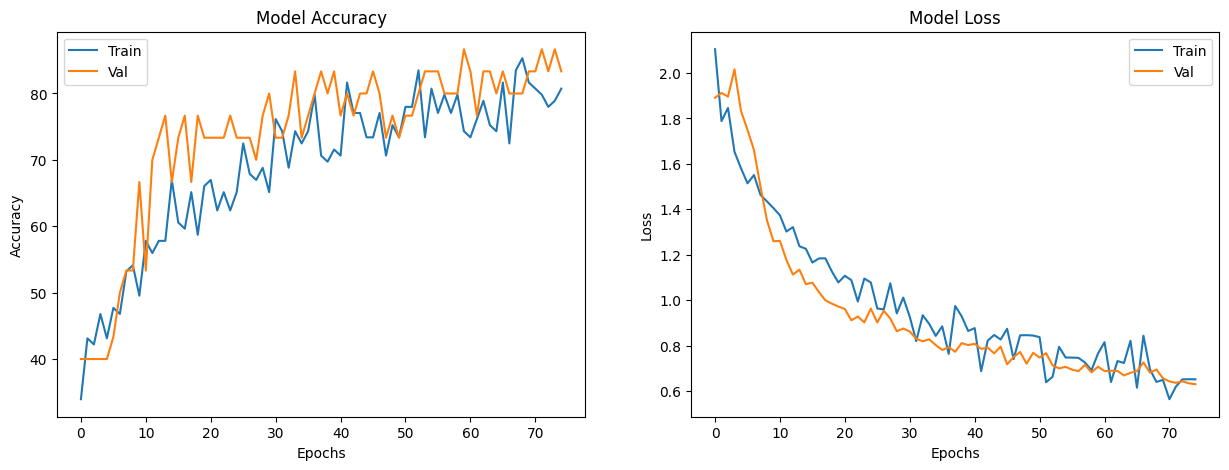

In [108]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plotting training and validation accuracy
ax[0].plot(train_accuracies)
ax[0].plot(val_accuracies)
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(['Train', 'Val'])

# Plotting training and validation loss
ax[1].plot(train_losses)
ax[1].plot(val_losses)
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(['Train', 'Val'])

plt.show()

## D. Evaluating Your Trained Model

### Load Trained Model and Evaluate

In [109]:
# Load the trained weights
model.load_state_dict(torch.load('model_classification.pth'))

# Set the model to evaluation mode
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in val_loader:

        images = images.cuda()
        images = (images) / 255.

        labels = labels.cuda()
        labels = labels.long()

        outputs = model(images)

        predicted = outputs.argmax(-1)
        print(predicted)
        print(labels)
        test_correct += (predicted == labels).sum().item()
        test_total += labels.size(0)

print(f'Test accuracy is {100. * test_correct / test_total}%')

tensor([0, 0, 0, 1, 4, 1, 4, 2], device='cuda:0')
tensor([0, 0, 0, 1, 1, 1, 2, 2], device='cuda:0')
tensor([2, 3, 3, 4, 4, 4, 4, 4], device='cuda:0')
tensor([2, 3, 3, 4, 4, 4, 4, 4], device='cuda:0')
tensor([2, 4, 4, 4, 4, 4, 4, 5], device='cuda:0')
tensor([4, 4, 4, 4, 4, 4, 4, 5], device='cuda:0')
tensor([5, 5, 6, 6, 7, 4], device='cuda:0')
tensor([5, 5, 6, 6, 7, 7], device='cuda:0')
Test accuracy is 86.66666666666667%
